# 🏠 House Prices — 01. EDA & Feature Engineering
**Responsável:** Vitor  
**Dataset:** [Kaggle - House Prices: Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data)

**Objetivo:** Este notebook cumpre o objetivo de Análise Exploratória de Dados (EDA) e Feature Engineering. Aqui realizamos a investigação inicial das variáveis, identificação e tratamento de outliers, e as transformações matemáticas (imputação, normalização e encoding) necessárias para modelagem.

---
## 📦 0. Importações

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Configurações visuais
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


---
## 📂 1. Carregamento dos Dados

In [2]:
data_path = '../data/train.csv'
df = pd.read_csv(data_path)

print(f"Shape inicial do dataset: {df.shape}")
df.head(3)

Shape inicial do dataset: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


---
## 📊 2. Análise Exploratória de Dados (EDA)

Antes de transformar os dados, exploramos sua distribuição, correlações e valores faltantes.

C:\Users\vdmas\AppData\Local\Temp\ipykernel_46892\3104850449.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing.values, y=missing.index, palette='Reds_r', ax=ax[1])


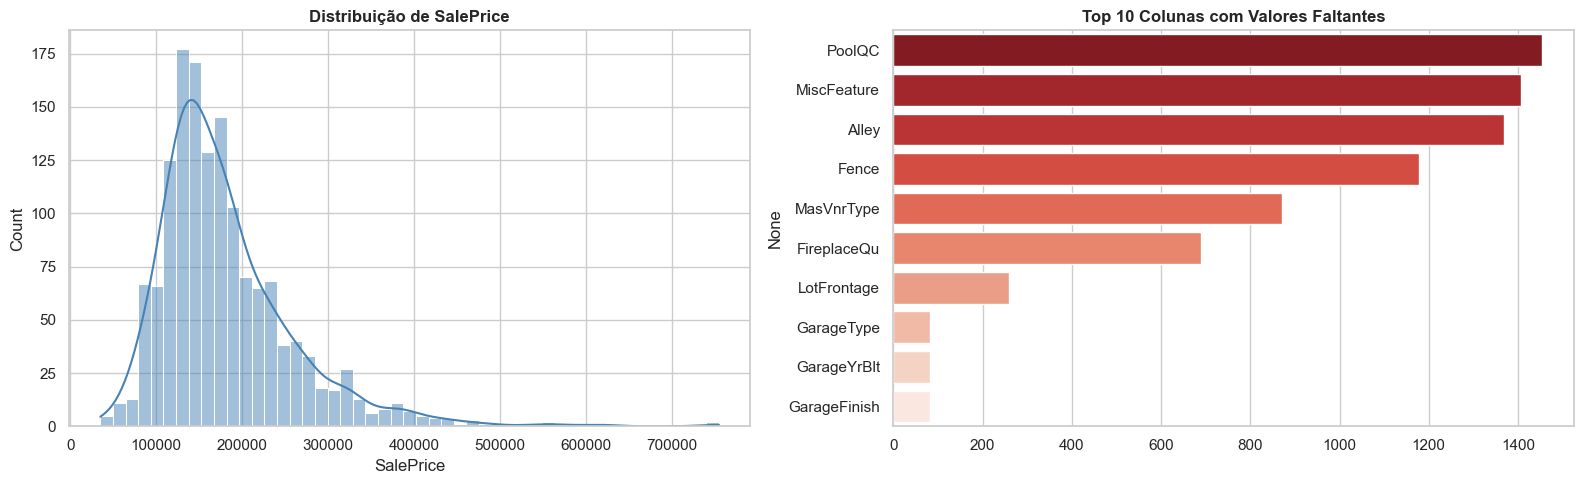

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# 1. Distribuição da Variável Alvo
sns.histplot(df['SalePrice'], kde=True, color='steelblue', ax=ax[0])
ax[0].set_title('Distribuição de SalePrice', fontweight='bold')

# 2. Top 10 features com mais valores faltantes
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False).head(10)
sns.barplot(x=missing.values, y=missing.index, palette='Reds_r', ax=ax[1])
ax[1].set_title('Top 10 Colunas com Valores Faltantes', fontweight='bold')

plt.tight_layout()
plt.show()

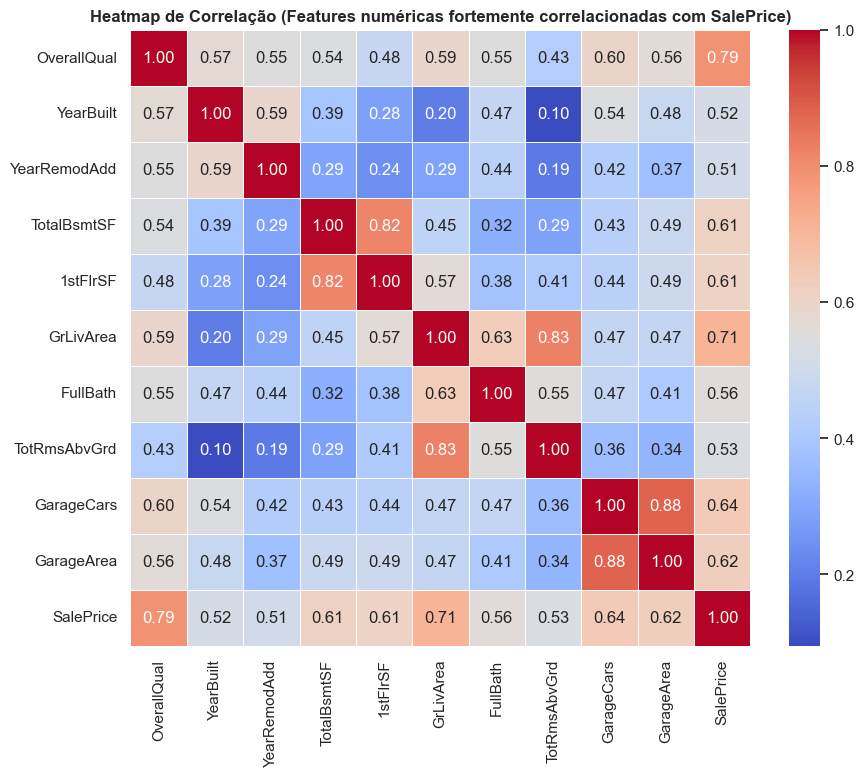

In [4]:
plt.figure(figsize=(10, 8))
df_num = df.select_dtypes(include=[np.number])
corr = df_num.corr()
top_corr_features = corr.index[abs(corr["SalePrice"]) > 0.5]

sns.heatmap(df[top_corr_features].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title('Heatmap de Correlação (Features numéricas fortemente correlacionadas com SalePrice)', fontweight='bold')
plt.show()

---
## 🚨 3. Tratamento de Outliers

Ao plotar a área habitável (`GrLivArea`) vs o preço (`SalePrice`), notamos classicamente neste dataset a presença de casas com mais de 4.000 pés quadrados que foram vendidas por preços anormalmente baixos. 

Para evitar que nossos modelos aprendam esse ruído, faremos a remoção segura desses *outliers* gritantes.

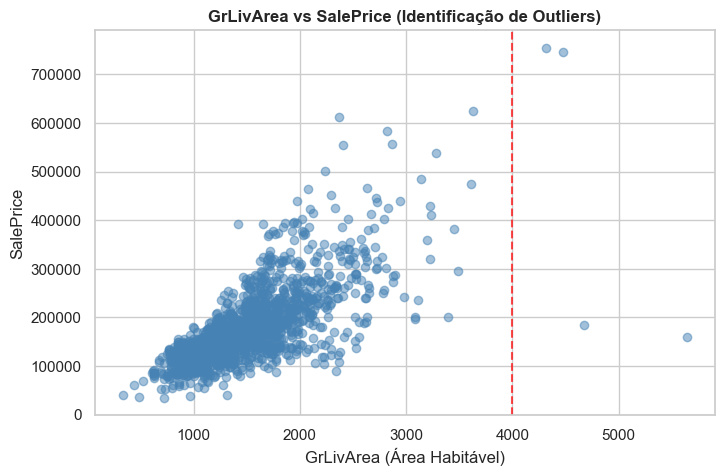

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5, color='steelblue')
ax.axvline(x=4000, color='red', linestyle='--', alpha=0.7)
ax.set_title('GrLivArea vs SalePrice (Identificação de Outliers)', fontweight='bold')
ax.set_xlabel('GrLivArea (Área Habitável)')
ax.set_ylabel('SalePrice')
plt.show()

In [6]:
outliers = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
print(f"Outliers identificados para remoção: {len(outliers)}")

# Removemos os outliers da base
df = df.drop(outliers.index).reset_index(drop=True)
print(f"Novo shape do dataset: {df.shape}")

Outliers identificados para remoção: 2
Novo shape do dataset: (1458, 81)


---
## 🔧 4. Feature Engineering

Aplicamos as seguintes transformações:
1. **Separação:** Isolamos o `Id` e o `SalePrice`.
2. **Numéricas:** Imputação com a *Mediana* + Normalização (*StandardScaler*).
3. **Categóricas:** Imputação com a *Moda* + Codificação em variáveis dummy (*OneHotEncoder*).

In [7]:
TARGET = 'SalePrice'
ID_COL = 'Id'

y = df[TARGET]
X = df.drop(columns=[TARGET, ID_COL])

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"Features Numéricas: {len(numeric_features)}")
print(f"Features Categóricas: {len(categorical_features)}")

Features Numéricas: 36
Features Categóricas: 43


C:\Users\vdmas\AppData\Local\Temp\ipykernel_46892\1853100059.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object']).columns.tolist()


In [8]:
# Pipelines independentes
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Transformador de colunas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Aplica as transformações no dataset completo
X_processed = preprocessor.fit_transform(X)

# Recupera os nomes gerados pelo OneHotEncoder
cat_cols_encoded = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
all_columns = numeric_features + list(cat_cols_encoded)

# Monta o DataFrame final
X_df = pd.DataFrame(X_processed, columns=all_columns)
print(f"Shape do dataset após Feature Engineering: {X_df.shape}")

Shape do dataset após Feature Engineering: (1458, 286)


---
## 💾 5. Exportação do Dataset Processado

O dataset padronizado, binarizado e sem outliers é exportado. O target `SalePrice` é devolvido à base na sua escala original para que as métricas dos modelos subsequentes permaneçam em dólares.

In [9]:
# Reintegra o Id e o Target
X_df.insert(0, ID_COL, df[ID_COL].values)
X_df[TARGET] = y.values

out_path = '../data/train_processed.csv'
X_df.to_csv(out_path, index=False)

print(f"✅ Dataset processado e salvo com sucesso em: {out_path}")
print(f"   Valores Nulos: {X_df.isnull().sum().sum()}")
print(f"   Total de Colunas (após OHE): {X_df.shape[1]}")

✅ Dataset processado e salvo com sucesso em: ../data/train_processed.csv
   Valores Nulos: 0
   Total de Colunas (após OHE): 288
